## Baseline & Campaign Performance.

In [36]:
# BASELINE CONVERSION RATE (on cleaned data)

total_clients = len(df_clean)
total_subscribed = df_clean['y_binary'].sum()
total_not_subscribed = total_clients - total_subscribed
baseline_rate = df_clean['y_binary'].mean() * 100

print("CAMPAIGN BASELINE METRICS")
print(f"Total clients contacted:   {total_clients:,}")
print(f"Total subscribed:          {total_subscribed:,}")
print(f"Total did not subscribe:   {total_not_subscribed:,}")
print(f"Baseline conversion rate:  {baseline_rate:.2f}%")

# 95% confidence interval around the baseline
from statsmodels.stats.proportion import proportion_confint
ci_low, ci_high = proportion_confint(
    count=total_subscribed, nobs=total_clients, alpha=0.05, method='wilson'
)
print(f"95% Confidence Interval:   [{ci_low*100:.2f}%, {ci_high*100:.2f}%]")

CAMPAIGN BASELINE METRICS
Total clients contacted:   41,176
Total subscribed:          4,639
Total did not subscribe:   36,537
Baseline conversion rate:  11.27%
95% Confidence Interval:   [10.96%, 11.58%]


In [37]:
# CAMPAIGN EFFICIENCY METRICS

calls_per_conversion = total_clients / total_subscribed
effort_waste_rate = (total_not_subscribed / total_clients) * 100

print("CAMPAIGN EFFICIENCY")
print(f"Calls per subscription:    {calls_per_conversion:.1f}")
print(f"Effort waste rate:         {effort_waste_rate:.1f}%")
print(f"Non-conversion calls:      {total_not_subscribed:,}")
print(f"\nInterpretation: For every 1 subscriber acquired, the bank made")
print(f"{calls_per_conversion:.1f} calls — {effort_waste_rate:.1f}% of which did not convert.")

CAMPAIGN EFFICIENCY
Calls per subscription:    8.9
Effort waste rate:         88.7%
Non-conversion calls:      36,537

Interpretation: For every 1 subscriber acquired, the bank made
8.9 calls — 88.7% of which did not convert.


In [38]:
# MONTH-LEVEL VOLUME vs EFFECTIVENESS

month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_stats = df_clean.groupby('month').agg(
    calls=('y_binary', 'count'),
    subscriptions=('y_binary', 'sum'),
    conversion_rate=('y_binary', 'mean')
).reindex(month_order)
month_stats['conversion_rate'] = (month_stats['conversion_rate'] * 100).round(2)
month_stats['call_share'] = (month_stats['calls'] / total_clients * 100).round(2)
month_stats['lift'] = (month_stats['conversion_rate'] / baseline_rate).round(2)

print("MONTH-LEVEL PERFORMANCE")
print(month_stats.to_string())

MONTH-LEVEL PERFORMANCE
       calls  subscriptions  conversion_rate  call_share  lift
month                                                         
mar      546            276            50.55        1.33  4.49
apr     2631            539            20.49        6.39  1.82
may    13767            886             6.44       33.43  0.57
jun     5318            559            10.51       12.92  0.93
jul     7169            648             9.04       17.41  0.80
aug     6176            655            10.61       15.00  0.94
sep      570            256            44.91        1.38  3.99
oct      717            315            43.93        1.74  3.90
nov     4100            416            10.15        9.96  0.90
dec      182             89            48.90        0.44  4.34


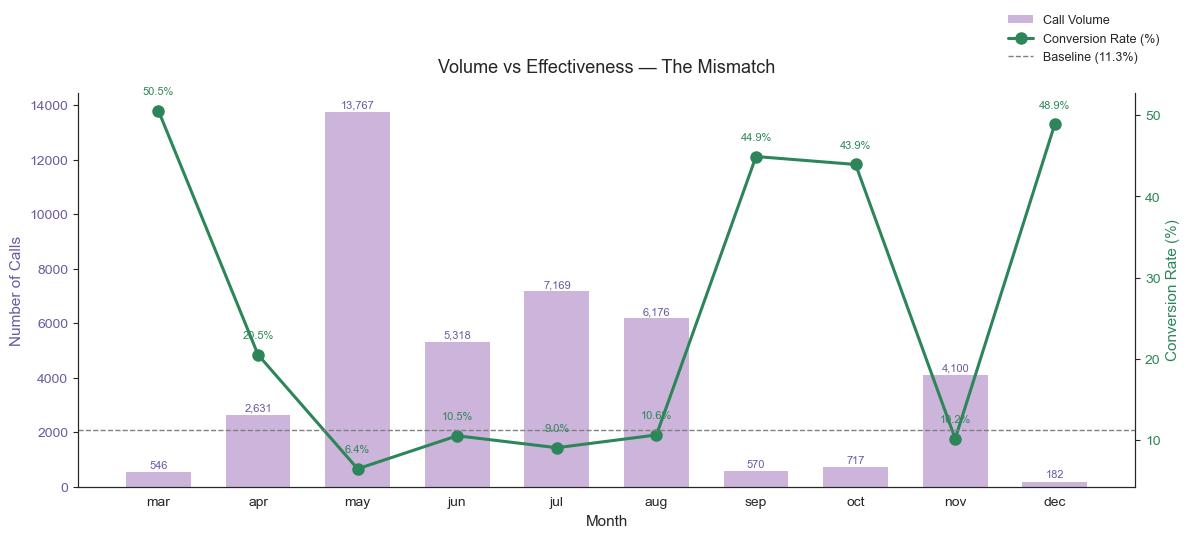

In [39]:
# VOLUME vs CONVERSION — THE CENTERPIECE CHART

fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar chart: call volume
x = np.arange(len(month_stats))
bars = ax1.bar(
    x,
    month_stats['calls'],
    color='#cdb4db',   
    edgecolor='none',
    label='Call Volume',
    width=0.65
)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Number of Calls', fontsize=11, color='#6d5aa0')
ax1.set_xticks(x)
ax1.set_xticklabels(month_stats.index)
ax1.tick_params(axis='y', labelcolor='#6d5aa0')

# Add call count labels on bars
for i, v in enumerate(month_stats['calls']):
    ax1.text(i, v + 150, f'{int(v):,}', ha='center', fontsize=8, color='#6d5aa0')

# Line chart: conversion rate (secondary axis)
ax2 = ax1.twinx()
ax2.plot(x, month_stats['conversion_rate'], color='#2d8659',
         marker='o', markersize=8, linewidth=2.2, label='Conversion Rate (%)')
ax2.set_ylabel('Conversion Rate (%)', fontsize=11, color='#2d8659')
ax2.tick_params(axis='y', labelcolor='#2d8659')
ax2.axhline(baseline_rate, color='gray', linestyle='--', linewidth=1,
            label=f'Baseline ({baseline_rate:.1f}%)')

# Add conversion rate labels on line points
for i, v in enumerate(month_stats['conversion_rate']):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=8, color='#2d8659')

plt.title('Volume vs Effectiveness — The Mismatch', fontsize=13, pad=15)
fig.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 1.08),  # move higher
    frameon=False,
    fontsize=9
)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

In [40]:
# CURRENT STATE SUMMARY

summary = pd.DataFrame({
    'Metric': [
        'Total Calls Made',
        'Total Subscribers',
        'Baseline Conversion Rate',
        'Calls per Subscriber',
        'Effort Waste Rate',
        'Top-Volume Month',
        'Top-Volume Month Conversion',
        'Top-Converting Month',
        'Top-Converting Month Conversion',
        'Top vs Bottom Month Spread'
    ],
    'Value': [
        f'{total_clients:,}',
        f'{total_subscribed:,}',
        f'{baseline_rate:.2f}%',
        f'{calls_per_conversion:.1f}',
        f'{effort_waste_rate:.1f}%',
        month_stats['calls'].idxmax(),
        f"{month_stats.loc[month_stats['calls'].idxmax(), 'conversion_rate']:.2f}%",
        month_stats['conversion_rate'].idxmax(),
        f"{month_stats['conversion_rate'].max():.2f}%",
        f"{month_stats['conversion_rate'].max() - month_stats['conversion_rate'].min():.1f} pp"
    ]
})

print("CURRENT STATE SUMMARY")
print("-"*40)
print(summary.to_string(index=False))

CURRENT STATE SUMMARY
----------------------------------------
                         Metric   Value
               Total Calls Made  41,176
              Total Subscribers   4,639
       Baseline Conversion Rate  11.27%
           Calls per Subscriber     8.9
              Effort Waste Rate   88.7%
               Top-Volume Month     may
    Top-Volume Month Conversion   6.44%
           Top-Converting Month     mar
Top-Converting Month Conversion  50.55%
     Top vs Bottom Month Spread 44.1 pp
